# ⚙️ Preprocesamiento de Datos Magnetotelúricos
---
**Curso:** Magnetotelúrica desde Cero: Fundamentos, Procesamiento e Interpretación de Datos  
**Módulo 3 — Análisis e Interpretación de Datos MT**

En este notebook se realiza el **preprocesamiento** de los datos MT crudos:
1. Carga del H5 crudo generado en el Notebook 1.
2. **Inspección y eliminación** de frecuencias con alta dispersión (outliers).
3. **Interpolación** de las curvas a una grilla de periodos común.
4. Exportación de los datos procesados como nuevos archivos EDI y H5.

> **Prerequisito:** Haber ejecutado el Notebook 1 y tener el archivo
> `h5/collection_crudo.h5` disponible en la carpeta h5. Haber creado una copia del archivo h5  `collection_crudo.h5` en la carpeta "h5_procesado" y cambiarle el nombre a `collection_procesado.h5`, para no modificar el archivo original.

<div style="background:#f0f9ef;border-left:5px solid #27AE60;padding:10px 14px;border-radius:4px;margin:6px 0">El <b>preprocesamiento</b> MT tiene dos objetivos principales:<br>1. <b>Limpieza:</b> eliminar frecuencias contaminadas por ruido cultural (líneas de transmisión, ferrocarriles, etc.) o ruido instrumental. Esto se hace inspeccionando visualmente cada sondeo y eliminando puntos que se alejan de la tendencia suave de las curvas ρ<sub>a</sub> y φ.<br>2. <b>Interpolación:</b> llevar todos los sondeos a la misma grilla de periodos, requerimiento indispensable para el análisis.</div>

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 1 · Importar librerías</span></div>


In [1]:
# Importar librerías
from pathlib import Path
from mtpy import MT, MTData, MTCollection
import h5py
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 2 · Cargar datos y visualizar sondeos originales</span></div>

### Flujo de trabajo del preprocesamiento

```
H5 crudo  →  MTCollection  →  MTData  →  inspección visual  →  interpolación
                                                              ↓
                                                      EDIs procesados
                                                              ↓
                                                      H5 procesado
```

Abrimos la colección que contiene el h5_procesado y convertimos a MTData 

In [2]:
# Convertir a MTData
with MTCollection() as mc:
    mc.open_collection(Path("h5_procesado/collection_procesado.h5")) # Ruta del h5 crudo
    mtd = mc.to_mt_data()

26:03:17T15:26:02 | INFO | line:777 |mth5.mth5 | close_mth5 | Flushing and closing h5_procesado\collection_procesado.h5


In [3]:
mtd.station_locations

,survey,station,latitude,longitude,elevation,datum_epsg,east,north,utm_epsg,model_east,model_north,model_elevation,profile_offset
0,edi,P,7.611,-73.609917,79.8766,4326,0.0,0.0,None,0.0,0.0,79.8766,0.0


<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 4 · Interpolar los datos</span></div>

<div style="background:#f0f9ef;border-left:5px solid #27AE60;padding:10px 14px;border-radius:4px;margin:6px 0">La <b>interpolación</b> en MT se realiza en el dominio del logaritmo del periodo (log-periodo), ya que las curvas son suaves en esa escala. <code>np.logspace(a, b, n)</code> genera <i>n</i> puntos equiespaciados en escala logarítmica entre 10<sup>a</sup> y 10<sup>b</sup> segundos. El rango debe estar <b>dentro del rango medido</b> de todos los sondeos para evitar extrapolación.</div>

In [4]:
new_periods = np.logspace(-2.4, 1, 50)

In [5]:
interpolated_mtd = mtd.interpolate(new_periods, inplace=False)

In [6]:
interpolated_mtd

MTData([('edi.P',
         TF( survey='edi', station='P', latitude=7.61, longitude=-73.61, elevation=79.88 ))])

**Datos originales**

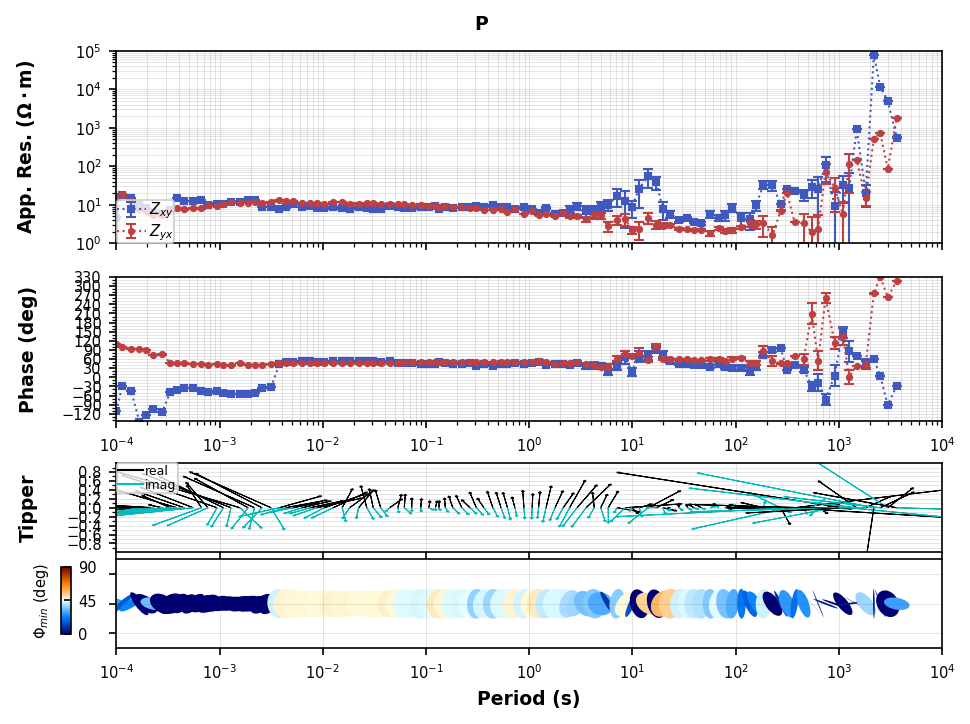

In [7]:
try:
    mtd.plot_mt_response("edi.P") # Nombre de la estación
except:
    pass

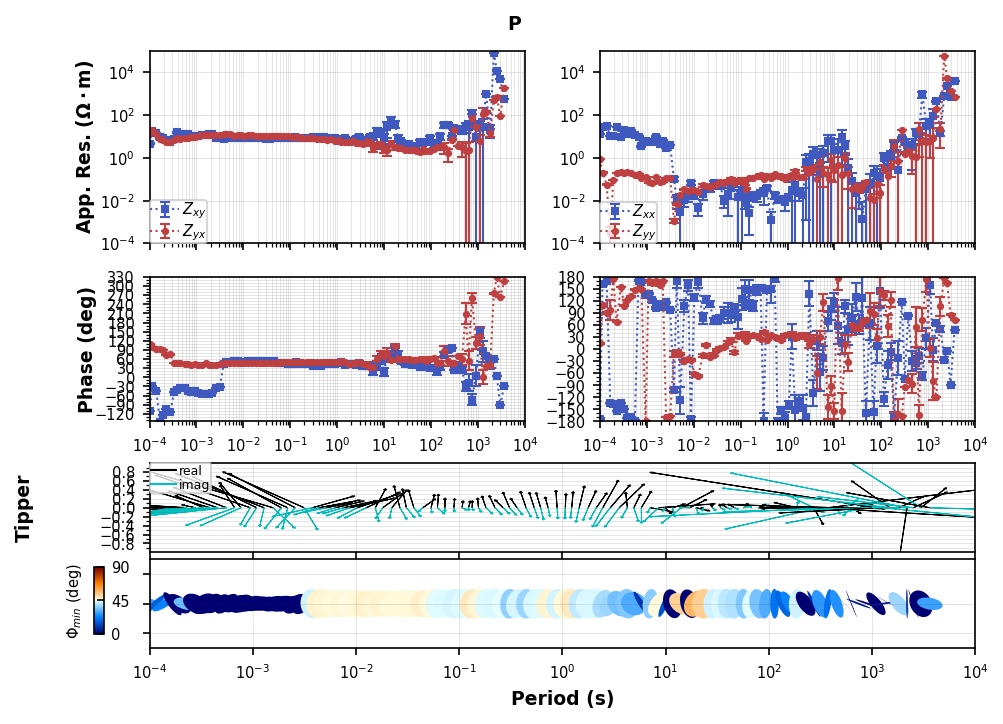

In [8]:
try:
    mt_object = mtd.get_station("P", survey_id="edi")
    plot_obj = mt_object.plot_mt_response(show_plot=False)
    plot_obj.plot_num = 2
    plot_obj.plot()
except:
    pass

**Datos interpolados**

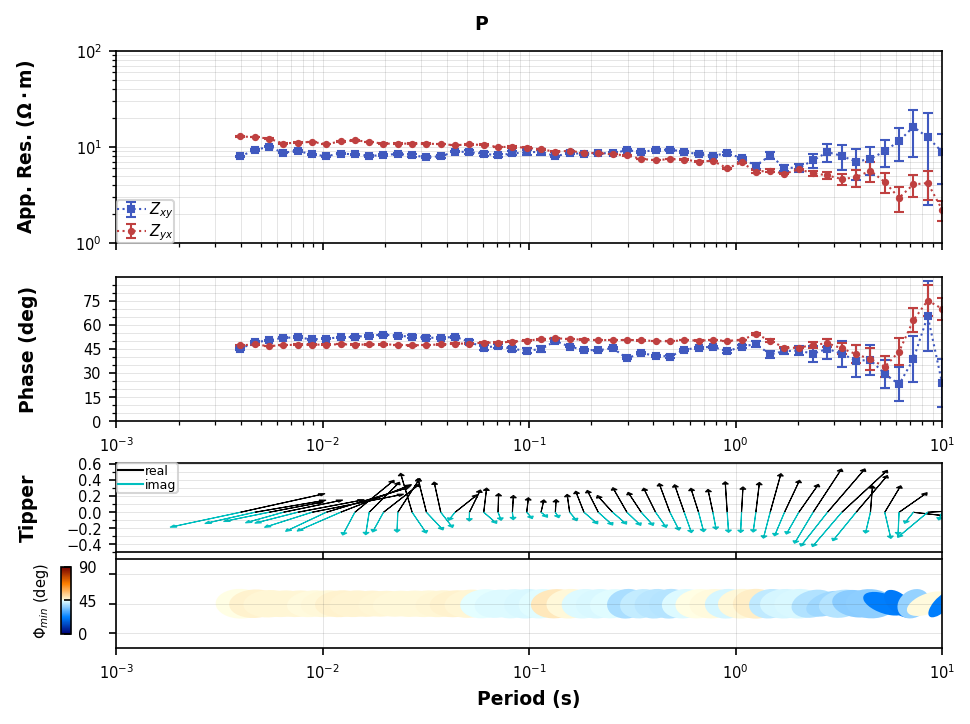

In [9]:
try:
    interpolated_mtd.plot_mt_response("edi.P") # Nombre de la estación
except:
    pass

<div style="background:#eaf4fb;border-left:5px solid #2980B9;padding:10px 14px;border-radius:4px;margin:6px 0">💡 <b>Tip:</b> Compara los gráficos del sondeo original con el interpolado. Las curvas deben seguir la misma tendencia pero con puntos regularmente espaciados.</div>

# Convertir a MTData para exportar el edi procesado en MTpy

<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 6 · Exportar sondeos interpolados como EDI</span></div>

### ¿Por qué exportar a EDI?
Aunque MTpy trabaja internamente con H5, el formato **EDI sigue siendo el estándar**
de interoperabilidad con otros software (WinGLink, ModEM, Occam, etc.).
Exportamos cada sondeo interpolado a un EDI individual.


In [10]:
# Exportar una sola estación interpolada como EDI procesado
from copy import deepcopy

try:
    from mt_metadata.transfer_functions.tf.station import Station
except Exception:
    Station = None

edi_procesados = Path("Edi_procesado")
edi_procesados.mkdir(parents=True, exist_ok=True)

station_id = "P"
survey_id = "edi"
out_fn = edi_procesados / f"{station_id}_procesado.edi"

# Obtener la estación interpolada
t = interpolated_mtd.get_station(station_id, survey_id=survey_id)

# Trabajar sobre una copia para no alterar el objeto interpolado original
try:
    mt_to_write = deepcopy(t)
except Exception:
    mt_to_write = t

# Limpiar station_metadata
if Station is not None:
    clean_station = None

    try:
        station_dict = mt_to_write.station_metadata.to_dict(single=True)

        if "station" in station_dict:
            filtered_station = {
                k: v
                for k, v in station_dict["station"].items()
                if not str(k).startswith("stations")
            }
            clean_station = Station()
            clean_station.from_dict({"station": filtered_station})
    except Exception as error:
        print(f"No se pudo reconstruir station_metadata desde dict: {error}")

    if clean_station is None:
        clean_station = Station()
        sm = mt_to_write.station_metadata

        try:
            clean_station.id = getattr(sm, "id", station_id) or station_id
        except Exception:
            clean_station.id = station_id

        for attr in [
            "location.latitude",
            "location.longitude",
            "location.elevation",
            "location.datum",
            "location.declination.value",
            "time_period.start",
            "time_period.end",
            "geographic_name",
            "data_type",
        ]:
            try:
                value = sm.get_attr_from_name(attr)
                if value not in [None, "", [], {}]:
                    clean_station.set_attr_from_name(attr, value)
            except Exception:
                pass

        try:
            clean_station.transfer_function = deepcopy(sm.transfer_function)
        except Exception:
            pass

        try:
            for run in sm.runs:
                clean_station.add_run(deepcopy(run))
        except Exception:
            pass

    mt_to_write.station_metadata = clean_station

mt_to_write.write(fn=out_fn)
print(f"Archivo EDI exportado correctamente: {out_fn}")

Archivo EDI exportado correctamente: Edi_procesado\P_procesado.edi


<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 7 · Crear H5 procesado desde los EDIs exportados</span></div>

In [11]:
# ── Generar el H5 procesado cargando los EDIs procesados ─────────────────────
# Este H5 será el punto de entrada de los notebooks Análisis e Inversión
edi_procesados = Path("Edi_procesado")
h5_fn = Path("h5_procesado/"+"collection_procesado_interpolado.h5")
h5_fn.parent.mkdir(parents=True, exist_ok=True)

with MTCollection() as mc:
    mc.open_collection(h5_fn, mode="a")

    for edi_filename in mc.make_file_list(edi_procesados, file_types=["edi"]):
        try:
            mt_object = MT()
            mt_object.read(edi_filename)

            # Asignar el survey para agrupar estos EDI
            mt_object.survey_metadata.id = "edi"

            mc.add_tf(mt_object)
            print(f"Agregado: {edi_filename.name}")

        except Exception as e:
            print(f"Error con {edi_filename.name}: {e}")

26:03:17T15:26:18 | WARNING | line:256 |mtpy.core.mt_collection | add_tf | If you are adding multiple transfer functions, suggest making a list of transfer functions first then adding the list using mt_collection.add_tf([list_of_tfs]). Otherwise adding transfer functions one by one will be slow.
26:03:17T15:26:18 | INFO | line:399 |mtpy.core.mt_collection | _from_mt_object | added edi.P
Agregado: P_procesado.edi
26:03:17T15:26:18 | INFO | line:777 |mth5.mth5 | close_mth5 | Flushing and closing h5_procesado\collection_procesado_interpolado.h5


<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷 8 · Visualización y verificación final de los datos procesados</span></div>

In [12]:
try:
     mc.plot_mt_response()
except:
    pass

In [13]:
# Obtener las frecuencias de cada sondeo

edi_path = Path("Edi_procesado")

frecuencias = []
for station in mc.make_file_list(edi_path, file_types=["edi"]):
    mt_object = MT(station) # Crea un objeto MT de cada edi
    mt_object.read() # Lee el objeto
    frecuencias.extend(1 / mt_object.Z.period)  # Convertir periodos a frecuencias

# Convertir a un array de numpy para mayor eficiencia
frecuencias = np.array(frecuencias)
print(frecuencias.shape)

(50,)


In [14]:
# Obtener las frecuencias de cada sondeo

frecuencia = []
for station in mc.make_file_list(edi_procesados, file_types=["edi"]):
    mt_object = MT(station) # Crea un objeto MT de cada edi
    mt_object.read() # Lee el objeto
    frecuencia.append(1 / mt_object.Z.period)  # Convertir periodos a frecuencias
len(frecuencia)

1

In [15]:
estaciones =[]
for station_tf in mtd.mt_list:  
    station_id = station_tf.station 
    estaciones.append(station_id)

len(estaciones)

1

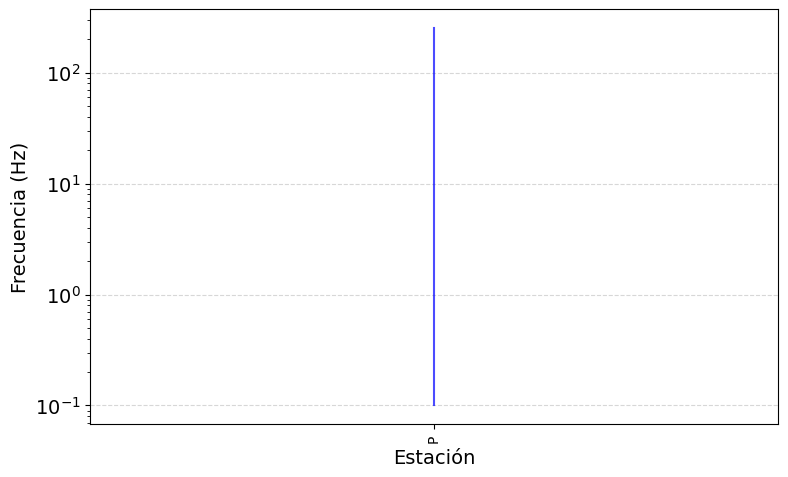

In [16]:
import os
# Definir el nombre de la carpeta y el archivo
folder_path = 'figuras'  # Carpeta donde quieres guardar la imagen
filename = "Frecuencias por estación.png"  # Nombre del archivo

plt.figure(figsize=(8, 5))

for idx, freqs in enumerate(frecuencia):  # Iterar sobre las frecuencias de cada estación
    station_id = estaciones[idx]       # Obtener el ID de la estación
    plt.plot([station_id] * len(freqs), freqs, '-', color="blue", alpha=0.7)  # Graficar cada frecuencia

plt.yscale("log")
plt.xlabel("Estación", fontsize=14)
plt.ylabel("Frecuencia (Hz)", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=14)
fig_path = os.path.join(folder_path, filename)
plt.savefig(fig_path, dpi=300, bbox_inches='tight', format="png")

plt.show()

In [17]:
freq_min = freqs.min()
print(f"[P] Frecuencia mínima = {freq_min:.3e} Hz")
print(f"[P] Frecuencia mínima = 10^{np.log10(freq_min):.2f} Hz")

[P] Frecuencia mínima = 1.000e-01 Hz
[P] Frecuencia mínima = 10^-1.00 Hz


In [18]:
freq_max = freqs.max()
print(f"[P] Frecuencia máxima = {freq_max:.3e} Hz")
print(f"[P] Frecuencia máxima = 10^{np.log10(freq_max):.2f} Hz")

[P] Frecuencia máxima = 2.512e+02 Hz
[P] Frecuencia máxima = 10^2.40 Hz


<div style="background:#2E86C1;padding:10px 16px;border-radius:6px;margin:18px 0 6px 0"><span style="color:white;font-size:1.2em;font-weight:bold">🔷9  · Cerrar la colección</span></div>

In [19]:
mc.close_collection() # Es importante siempre cerrar la colección para evitar daños en el archivo

26:03:17T15:26:20 | WARNING | line:330 |mth5.mth5 | filename | MTH5 file is not open or has not been created yet. Returning default name
26:03:17T15:26:20 | INFO | line:777 |mth5.mth5 | close_mth5 | Flushing and closing h5_procesado\collection_procesado_interpolado.h5
